## Imports

Disclaimer: Parts of this script were developed with the assistance of Microsoft Copilot

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from tqdm import tqdm

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from doctr.models import crnn_mobilenet_v3_small

## Paths and Configuration

### Image Configurations

In [60]:
TARGET_HEIGHT = 32
TARGET_WIDTH = 512

### Training Configuration

In [4]:
NUM_EPOCHS = 20

### Train Data

In [5]:
train_labels_csv_path = Path(
    r"L:\DATA\ISIS\2026-June-Model-Training\Dataset_Split\train\labels.csv"
    )

train_images_base_path = Path(
    r"L:\DATA\ISIS\2026-June-Model-Training\Dataset_Split\train"
    )

train_yolo_labels_base_path = Path(
    r"L:\DATA\ISIS\2026-June-Model-Training\Text_Detection\train\labels"
    )

### Validation Data

In [6]:
validation_labels_csv_path = Path(
    r"L:\DATA\ISIS\2026-June-Model-Training\Dataset_Split\validation\labels.csv"
    )

validation_images_base_path = Path(
    r"L:\DATA\ISIS\2026-June-Model-Training\Dataset_Split\validation"
    )

validation_yolo_labels_base_path = Path(
    r"L:\DATA\ISIS\2026-June-Model-Training\Text_Detection\validation\labels"
    )

### Test Data

In [7]:
test_labels_csv_path = Path(
    r"L:\DATA\ISIS\2026-June-Model-Training\Dataset_Split\test\labels.csv"
    )

test_images_base_path = Path(
    r"L:\DATA\ISIS\2026-June-Model-Training\Dataset_Split\test"
    )

test_yolo_labels_base_path = Path(
    r"L:\DATA\ISIS\2026-June-Model-Training\Text_Detection\test\labels"
    )

### Images That Failed Text Detection

In [8]:
failed_image_detections_csv_path = Path(
    r"L:\DATA\ISIS\2026-June-Model-Training\Text_Detection\failed_doctr_fast_adaptive_detections.csv"
    )

### Model Output and Fetching Path

In [ ]:
MODEL_PATH = Path(
    r"L:\DATA\ISIS\2026-June-Model-Training\Text_Recognition\crnn_mobilenet_finetuned.pt"
    )

## Load Metadata Labels

In [10]:
train_labels_df = pd.read_csv(train_labels_csv_path)
validation_labels_df = pd.read_csv(validation_labels_csv_path)
test_labels_df = pd.read_csv(test_labels_csv_path)

### Retrieve Failed Text Detections

In [11]:
failed_detections_df = pd.read_csv(failed_image_detections_csv_path)
failed_train_detections = list()
failed_validation_detections = list()
failed_test_detections = list()

for _, row in failed_detections_df.iterrows():
    split_type = row['split']
    relative_path = row['relative_path']

    if split_type == 'train':
        failed_train_detections.append(relative_path)
    elif split_type == 'validation':
        failed_validation_detections.append(relative_path)
    elif split_type == 'test':
        failed_test_detections.append(relative_path)

failed_train_set = {str(p) for p in failed_train_detections}
failed_validation_set = {str(p) for p in failed_validation_detections}
failed_test_set = {str(p) for p in failed_test_detections}


### Exclude Failed Detections from Train, Validation, and Test DataFrames

In [12]:
train_labels_df = train_labels_df[
    ~train_labels_df['dataset_relative_image_path'].isin(failed_train_set)
]

validation_labels_df = validation_labels_df[
    ~validation_labels_df['dataset_relative_image_path'].isin(failed_validation_set)
]

test_labels_df = test_labels_df[
    ~test_labels_df['dataset_relative_image_path'].isin(failed_test_set)
]

## Helper Functions

### Crop Image using Yolo Labels

In [ ]:
def crop_yolo_box(image_path, yolo_path):
    image = cv2.imread(str(image_path))

    h, w = image.shape[:2]

    with open(yolo_path) as f:
        _, cx, cy, bw, bh = map(float, f.readline().split())

    x1 = int((cx - bw / 2) * w)
    y1 = int((cy - bh / 2) * h)
    x2 = int((cx + bw / 2) * w)
    y2 = int((cy + bh / 2) * h)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    return image[y1:y2, x1:x2]

### Reize and Pad Images

In [ ]:
def resize_and_pad(
    image,
    target_height=32,
    target_width=128,
    pad_value=255
):
    h, w = image.shape[:2]

    scale = min(
        target_width / w,
        target_height / h
    )

    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    image = cv2.resize(
        image,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    pad_left = (target_width - new_w) // 2
    pad_right = target_width - new_w - pad_left

    pad_top = (target_height - new_h) // 2
    pad_bottom = target_height - new_h - pad_top

    image = cv2.copyMakeBorder(
        image,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        cv2.BORDER_CONSTANT,
        value=(pad_value, pad_value, pad_value)
    )

    return image

### Generate Dataset

In [43]:
def generate_dataset(main_df, images_base_path, yolo_labels_base_path, target_height, target_width):
    
    data = []

    for _, row in main_df.iterrows():
        relative_image_path = Path(row["dataset_relative_image_path"])
        metadata_label = str(row["metadata_label"])

        image_path = images_base_path / relative_image_path
        yolo_path = yolo_labels_base_path / relative_image_path.with_suffix(".txt")

        crop = crop_yolo_box(
            image_path,
            yolo_path
        )

        crop = resize_and_pad(
            crop,
            target_height,
            target_width
        )

        data.append(
            (
                crop,
                metadata_label
            )
        )

    return data

## Data Preparation for Training

### Dataset Class

In [44]:
class OCRDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        image, text = self.data[idx]

        image = torch.from_numpy(image).float()

        if image.ndim == 2:
            image = image.unsqueeze(-1)

        image = image.permute(2, 0, 1)

        image /= 255.0

        return image, text

### Converting Data to Training Compatible Format

In [61]:
train_data = generate_dataset(
    train_labels_df,
    train_images_base_path,
    train_yolo_labels_base_path,
    TARGET_HEIGHT,
    TARGET_WIDTH
)

validation_data = generate_dataset(
    validation_labels_df,
    validation_images_base_path,
    validation_yolo_labels_base_path,
    TARGET_HEIGHT,
    TARGET_WIDTH
)

test_data = generate_dataset(
    test_labels_df,
    test_images_base_path,
    test_yolo_labels_base_path,
    TARGET_HEIGHT,
    TARGET_WIDTH
)


train_dataset = OCRDataset(train_data)
validation_dataset = OCRDataset(validation_data)
test_dataset = OCRDataset(test_data)

### Data Loaders

#### Helper Collate Function

In [18]:
def collate_fn(batch):
    images = torch.stack(
        [sample[0] for sample in batch]
    )

    texts = [
        sample[1]
        for sample in batch
    ]

    return images, texts

In [62]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle=True,
    collate_fn=collate_fn
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=62,
    shuffle=False,
    collate_fn=collate_fn

)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

## Model Training

In [ ]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

model = crnn_mobilenet_v3_small(
    pretrained=True,
    input_shape=(3,32,512)
)

model = model.to(device)

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5,
    weight_decay=1e-4
)

Verify images after resizing and padding

torch.Size([64, 3, 32, 512])


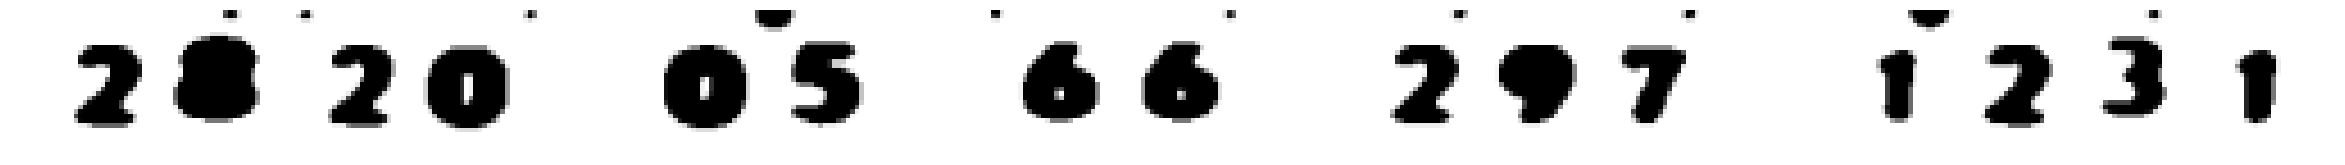

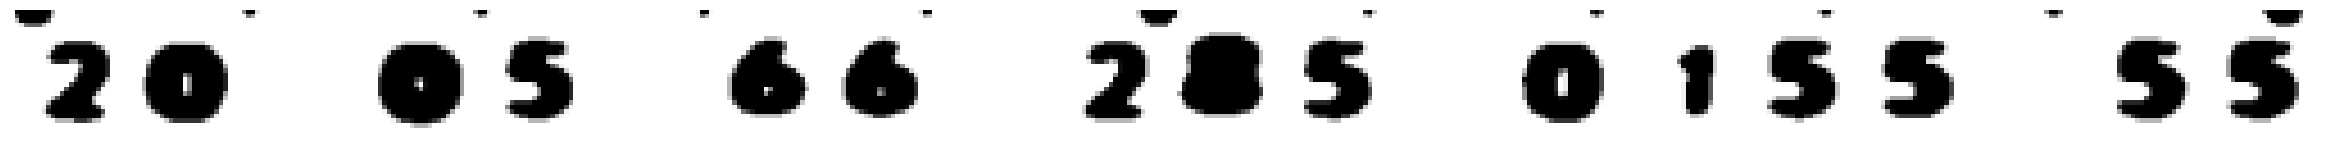

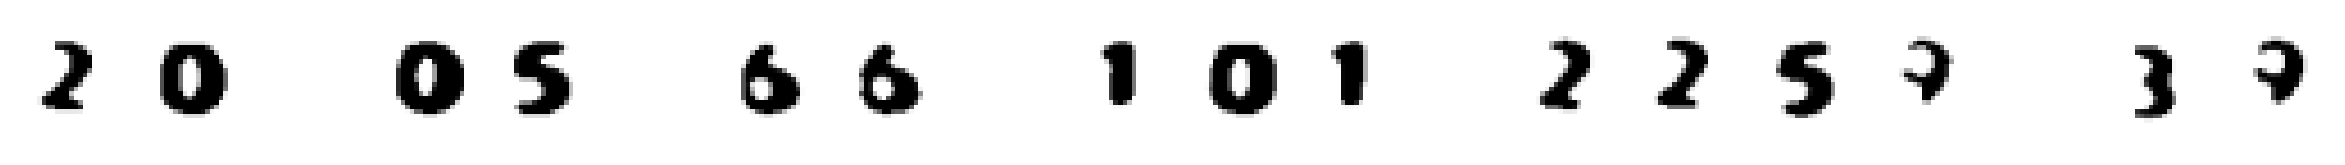

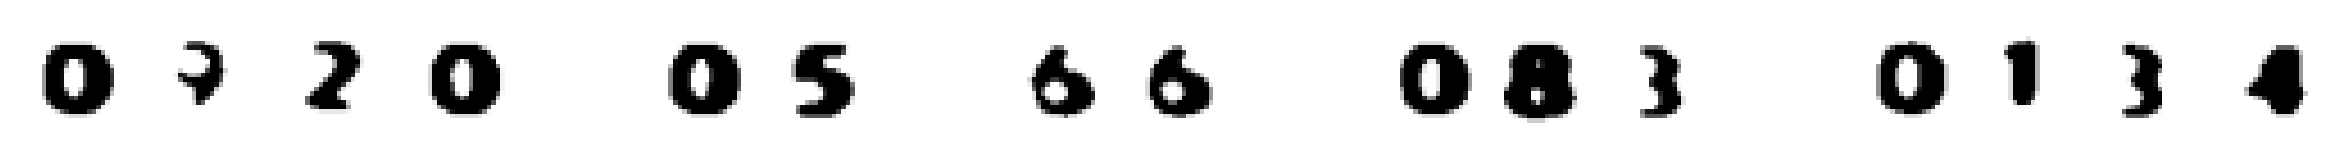

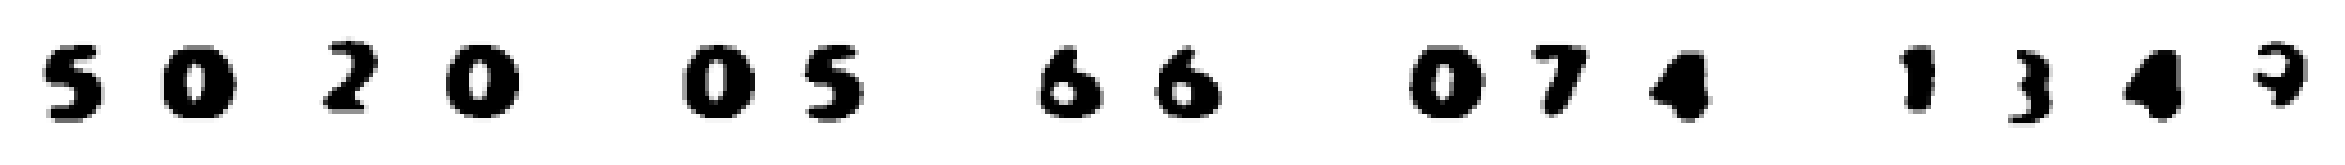

In [78]:
images, texts = next(iter(train_loader))

print(images.shape)

for i in range(5):
    img = images[i]
    img = img.permute(1,2,0).numpy()

    plt.figure(figsize=(30,2))
    plt.axis('off')
    plt.imshow(img)
    plt.show()


## Performance Validation

### Performance Validation Helper Functions

#### Character Level Accuracy Metric

In [69]:
def character_accuracy(gt, pred):
    max_len = max(len(gt), len(pred))

    if max_len == 0:
        return 1.0
    
    matches = sum(
        g==p
        for g, p in zip(gt, pred)
    )

    return matches / max_len

#### Exact Match Check

In [70]:
def exact_match_accuracy(gt, pred):
    return gt == pred

#### Model Evaluator

In [71]:
def evaluate_model(model, dataloader, device):

    model.eval()

    exact_correct = 0
    total = 0

    char_acc_sum = 0.0

    with torch.no_grad():

        for images, texts in dataloader:

            images = images.to(device)

            predictions = model(images)

            predicted_texts = [
                text
                for text, _ in predictions['preds']
            ]

            for gt, pred in zip(texts, predicted_texts):

                gt = str(gt)
                pred = str(pred)

                # print("GT:", gt)
                # print("PR:", pred)
                # print()

                total += 1

                if exact_match_accuracy(gt=gt, pred=pred):
                    exact_correct += 1

                char_acc_sum += character_accuracy(
                    gt,
                    pred
                )

    exact_accuracy = (
        exact_correct / total
        if total > 0
        else 0
    )

    character_level_accuracy = (
        char_acc_sum / total
        if total > 0
        else 0
    )

    return (
        exact_accuracy,
        character_level_accuracy
    )

### Training Loop

In [ ]:
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0

    for images, texts in tqdm(train_loader):
        
        images = images.to(device)
        optimizer.zero_grad()

        out = model(
            images,
            target=texts
        )

        loss = out['loss']

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    val_accuracy, _ = evaluate_model(
        model,
        validation_loader,
        device
    )

    print(
        f"Epoch {epoch+1}:\n"
        f"loss={running_loss / len(train_loader)}\n"
        f"val_accuracy={val_accuracy:.2%}\n"
    )

100%|██████████| 27/27 [00:34<00:00,  1.26s/it]


Epoch 1:
loss=0.6307437121868134
val_accuracy=80.52%



100%|██████████| 27/27 [00:34<00:00,  1.27s/it]


Epoch 2:
loss=0.47129757205645245
val_accuracy=79.32%



100%|██████████| 27/27 [00:38<00:00,  1.42s/it]


...

Epoch 18:
loss=0.14768303627217258
val_accuracy=83.73%



100%|██████████| 27/27 [00:33<00:00,  1.25s/it]


Epoch 19:
loss=0.14436056671871078
val_accuracy=84.74%



100%|██████████| 27/27 [00:34<00:00,  1.26s/it]


Epoch 20:
loss=0.13986014726537246
val_accuracy=85.34%



In [ ]:
for epoch in range(NUM_EPOCHS, NUM_EPOCHS*2):
    model.train()
    running_loss = 0

    for images, texts in tqdm(train_loader):
        
        images = images.to(device)
        optimizer.zero_grad()

        out = model(
            images,
            target=texts
        )

        loss = out['loss']

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    val_accuracy, _ = evaluate_model(
        model,
        validation_loader,
        device
    )

    print(
        f"Epoch {epoch+1}:\n"
        f"loss={running_loss / len(train_loader)}\n"
        f"val_accuracy={val_accuracy:.2%}\n"
    )

100%|██████████| 27/27 [00:34<00:00,  1.29s/it]


Epoch 21:
loss=0.13288786772776534
val_accuracy=85.74%



100%|██████████| 27/27 [00:35<00:00,  1.32s/it]


Epoch 22:
loss=0.1350226498864315
val_accuracy=86.55%



100%|██████████| 27/27 [00:33<00:00,  1.26s/it]


...

Epoch 38:
loss=0.09931028003080024
val_accuracy=91.16%



100%|██████████| 27/27 [00:34<00:00,  1.27s/it]


Epoch 39:
loss=0.0981837813914926
val_accuracy=91.16%



100%|██████████| 27/27 [00:34<00:00,  1.26s/it]


Epoch 40:
loss=0.09599200408491823
val_accuracy=91.37%



### Validate Model

#### Validation Data Performance Evaluation

In [72]:
val_exact_acc, val_char_acc = evaluate_model(
    model,
    validation_loader,
    device
)

print(
    f"Validation Exact Accuracy: "
    f"{val_exact_acc:.4f}"
)

print(
    f"Validation Character Accuracy: "
    f"{val_char_acc:.4f}"
)

Validation Exact Accuracy: 0.9137
Validation Character Accuracy: 0.9724


#### Test Data Performance Evaluation

In [73]:
test_exact_acc, test_char_acc = evaluate_model(
    model,
    test_loader,
    device
)

print(
    f"Test Exact Accuracy: "
    f"{test_exact_acc:.4f}"
)

print(
    f"Test Character Accuracy: "
    f"{test_char_acc:.4f}"
)

Test Exact Accuracy: 0.9333
Test Character Accuracy: 0.9794


## Save Model

In [74]:
torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("✅ Model was saved successfully!")

✅ Model was saved successfully!
